# PSD and Broadband Calculation Improvements

Erin Mee, 2/25/26

## Summary 

As part of the 2026 MSDS capstone project, some changes were made to the PSD and Broadband calculation method in [acoustic_utils](src/orcasound_noise/pipeline/acoustic_utils.py).

Summary of Calculation changes:

* wavelet denoising applied to PSD before converting to decibel units. Additionally, the scikit-image denoise_wavelet function requires values either in the range of [0,1] to [0,255], normalization before denoise_wavelet processing and denormalization after added.

* The short time Fourier transform function from librosa does not normalize for the windowing function used and sample rate. Normalization added, and resulting PSD verified by comparing to scipy short time Fourier transform since scipy's transform has options to output the transform in PSD correct units.

* Decibel sound level conversion updated to use the correct formula.

* Broadband calculation updated to use PSD in correct units.

## Imports

In [44]:
import pandas as pd
import polars as pl
import librosa
import numpy as np
import datetime as dt
from skimage.restoration import denoise_wavelet
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hann

In [14]:
from orcasound_noise.pipeline.acoustic_util import wav_to_array
from orcasound_noise.pipeline.acoustic_util import plot_spec, plot_bb

## Constants

In [15]:
# wav file of 10 min segment
wav_filepath = "wav_files/rpi-port-townsend_2026_02_03_23_50_00.wav"
t0 = dt.datetime(2026, 2, 4, 0, 0, 21)
delta_t = 1
delta_f = 1
bands = 12
ref = 1e-7

## Current method of Calculation PSD and Broadband

The following is the code found in the wav_to_array function of orcasound_noise

In [3]:
y, sr = librosa.load(wav_filepath, sr=None)
print(y, sr)

/home/erinmee/anaconda3/envs/orca_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[ 0.0000000e+00  0.0000000e+00 -1.5258789e-05 ... -3.3264160e-03
 -3.6315918e-03 -3.9215088e-03] 48000


In [4]:
# Set FFT parameters
n_fft = int(sr / delta_f)
hop_length = int(n_fft / 2)

Short term Fourier transform
$$
{\displaystyle \mathbf {STFT} \{x[n]\}(m,\omega )\equiv X(m,\omega )=\sum _{n=-\infty }^{\infty }x[n]w[n-m]e^{-i\omega n}}
$$
Where $w[n]$ is the windowing function and $x[n]$ is the signal

In [5]:
# Apply the STFT
D_highres = librosa.stft(y, hop_length=hop_length, n_fft=n_fft)
print(D_highres)

[[ 4.5491282e-02+0.0000000e+00j -7.9561824e-01+0.0000000e+00j
  -8.3764291e-01+0.0000000e+00j ...  3.4264923e+01+0.0000000e+00j
  -1.2482193e+01+0.0000000e+00j -9.4383020e+00+0.0000000e+00j]
 [-3.8513222e-01+4.4158021e-01j  1.0321095e-01+1.6014916e-01j
   2.7219024e-01-9.6715227e-02j ... -7.0360733e+01+5.6390214e+00j
   1.3692274e+00+1.3366549e+01j  1.0790843e+01+2.2506359e-01j]
 [-6.7774349e-01-1.6503419e+00j  1.8929532e+00+2.6646441e-01j
   1.3790864e+00-8.2731381e-02j ...  4.2485573e+01-4.8869748e+00j
   1.4999885e+01+7.7740431e+00j -8.5606785e+00-1.4536140e+00j]
 ...
 [-5.0089444e-04+3.7572299e-05j -4.8876955e-05-1.9519334e-04j
   2.4988633e-04-4.3514904e-04j ...  2.1586311e-05-1.4578787e-04j
  -4.0117462e-04-9.1022474e-04j  1.5101918e-03+2.0240273e-05j]
 [ 7.5693279e-05-4.6691281e-04j -1.0150361e-04+9.6616428e-04j
   2.9057474e-04-4.2919733e-04j ...  3.7162311e-04-9.8338314e-05j
   2.8101544e-04+4.7029188e-04j -1.6992388e-03+2.9665611e-05j]
 [ 4.1577159e-04+0.0000000e+00j  1.75361

amplitude_to_db performs the following calculation:
$$
20\log\frac{|D_{highres}|}{ref}
$$

In [6]:
# Convert from amplitude to decibels
spec = librosa.amplitude_to_db(np.abs(D_highres), ref=ref)
spec

array([[ 83.340164,  98.01409 ,  98.46118 , ..., 130.69699 , 121.92582 ,
        119.49788 ],
       [ 95.35699 ,  85.59909 ,  89.21381 , ..., 136.97441 , 122.56572 ,
        120.662994],
       [105.02832 , 105.62801 , 102.807434, ..., 132.62192 , 124.55503 ,
        118.77361 ],
       ...,
       [ 83.340164,  83.340164,  83.340164, ...,  83.340164,  83.340164,
         83.340164],
       [ 83.340164,  83.340164,  83.340164, ...,  83.340164,  83.340164,
         83.340164],
       [ 83.340164,  83.340164,  83.340164, ...,  83.340164,  83.340164,
         83.340164]], shape=(24001, 1201), dtype=float32)

In [7]:
# Save the frequencies and time for Dataframe construction
freqs = librosa.core.fft_frequencies(sr=sr, n_fft=n_fft)
secs = librosa.core.frames_to_time(np.arange(spec.shape[1]), sr=sr, n_fft=n_fft, hop_length=hop_length)
times = [t0 + dt.timedelta(seconds=x) for x in secs]

In [8]:
spec_denoise = denoise_wavelet(spec,
                               convert2ycbcr=False,
                               method="BayesShrink",
                               mode="soft")
print(spec_denoise)
print(spec_denoise.shape)

[[ 91.90518   92.49734   93.580505 ... 133.14171  123.41763  120.074326]
 [ 91.90518   92.49734   93.580505 ... 133.14171  123.41763  120.074326]
 [106.3338   107.59529  106.150734 ... 136.00183  130.12856  120.074326]
 ...
 [ 83.34016   83.34016   83.34016  ...  83.3453    83.3453    83.3453  ]
 [ 83.34016   83.34016   83.34016  ...  83.3453    83.3453    83.3453  ]
 [ 83.34016   83.34016   83.34016  ...  83.34298   83.34298   83.34298 ]]
(24001, 1201)


In [9]:
rms = []
delta_f = sr / n_fft
DT = D_highres.transpose()
# Sum over the frequencies for each time to calculate broadband
for i in range(len(DT)):
    rms.append(delta_f * np.sum(np.abs(DT[i, :])))
print(rms)

[np.float32(6888.498), np.float32(14013.248), np.float32(10373.83), np.float32(9302.197), np.float32(9494.253), np.float32(8725.414), np.float32(9036.301), np.float32(12255.163), np.float32(13314.514), np.float32(10195.238), np.float32(9301.726), np.float32(11783.117), np.float32(9566.299), np.float32(8507.126), np.float32(8688.394), np.float32(9211.517), np.float32(9209.506), np.float32(8463.604), np.float32(8011.558), np.float32(15332.436), np.float32(9169.244), np.float32(8333.154), np.float32(7815.2017), np.float32(8194.717), np.float32(10261.428), np.float32(10365.979), np.float32(10095.214), np.float32(9109.398), np.float32(8765.872), np.float32(11597.613), np.float32(8619.941), np.float32(10476.208), np.float32(8543.838), np.float32(9024.417), np.float32(9738.297), np.float32(17651.23), np.float32(13461.464), np.float32(9319.757), np.float32(8899.8955), np.float32(9186.114), np.float32(9731.369), np.float32(9117.303), np.float32(8078.177), np.float32(8481.767), np.float32(10128.

In [10]:
# Create PSD dataframe
spec_arr = np.asarray(spec_denoise.transpose(), dtype=np.float64)
np.around(spec_arr, 2, out=spec_arr)
df = pd.DataFrame(spec_arr, columns=freqs, index=times)
df.columns = df.columns.map(str)
df.head(5)

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,23991.0,23992.0,23993.0,23994.0,23995.0,23996.0,23997.0,23998.0,23999.0,24000.0
2026-02-04 00:00:21.500,91.91,91.91,106.33,106.33,105.80,105.80,114.66,114.66,118.50,118.50,...,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34
2026-02-04 00:00:22.000,92.50,92.50,107.60,107.60,104.79,104.79,114.85,114.85,114.36,114.36,...,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34
2026-02-04 00:00:22.500,93.58,93.58,106.15,106.15,116.12,116.12,123.52,123.52,127.32,127.32,...,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34
2026-02-04 00:00:23.000,90.79,90.79,104.99,104.99,116.12,116.12,107.46,107.46,119.60,119.60,...,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34
2026-02-04 00:00:23.500,103.42,103.42,115.23,115.23,124.36,124.36,126.78,126.78,129.32,129.32,...,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34,83.34


In [11]:
# Create the broadband dataframe with the same strategy
rms_arr = np.asarray(rms, dtype=np.float64)
rms_arr = librosa.amplitude_to_db(rms_arr, ref=1, top_db=200.0)
np.around(rms_arr, 2, out=rms_arr)
rms_df = pd.DataFrame(rms_arr, index=times)
rms_df.columns = rms_df.columns.map(str)
rms_df.head(10)

,0
2026-02-04 00:00:21.500,76.76
2026-02-04 00:00:22.000,82.93
2026-02-04 00:00:22.500,80.32
2026-02-04 00:00:23.000,79.37
2026-02-04 00:00:23.500,79.55
2026-02-04 00:00:24.000,78.82
2026-02-04 00:00:24.500,79.12
2026-02-04 00:00:25.000,81.77
2026-02-04 00:00:25.500,82.49
2026-02-04 00:00:26.000,80.17


## Updated Method for Calculating PSD and Broadband

In [16]:
y, sr = librosa.load(wav_filepath, sr=None)
# Set FFT parameters
n_fft = int(sr / delta_f)
hop_length = int(n_fft / 2)

In [17]:
# Apply the STFT
D_highres = librosa.stft(y, hop_length=hop_length, n_fft=n_fft)
D_abs = np.abs(D_highres)

The denoise_wavelet function expects values in [0,1] or [0,255] and crashes if there are values outside of the limits. Therefore denoise_wavelet is applied to the normalized stft transform waveform and then scaled back to original range.

In [18]:
# Normalize to [0, 1] for denoising
D_normalized = (D_abs - D_abs.min()) / (D_abs.max() - D_abs.min())
D_denoise = denoise_wavelet(D_normalized,
                               convert2ycbcr=False,
                               method="BayesShrink",
                               mode="soft")
# Scale back to original range
D_denoise = D_denoise * (D_abs.max() - D_abs.min()) + D_abs.min()
D_denoise

array([[4.6646792e-02, 7.9335511e-01, 8.3475173e-01, ..., 3.4267593e+01,
        1.2482596e+01, 9.4393673e+00],
       [5.8685398e-01, 1.9371425e-01, 2.9142204e-01, ..., 7.0583549e+01,
        1.3437136e+01, 1.0791647e+01],
       [1.7835033e+00, 1.9133019e+00, 1.3813822e+00, ..., 4.2768486e+01,
        1.6895245e+01, 8.6849804e+00],
       ...,
       [7.2592322e-04, 7.2592322e-04, 7.6071866e-04, ..., 4.9575930e-04,
        4.9575930e-04, 1.7624442e-03],
       [7.2592322e-04, 7.2592322e-04, 7.6071866e-04, ..., 4.9575930e-04,
        4.9575930e-04, 1.7624442e-03],
       [4.0492279e-04, 4.0492279e-04, 5.1937863e-04, ..., 4.1288097e-04,
        4.1288097e-04, 1.6825781e-03]], shape=(24001, 1201), dtype=float32)

To put the short term fourier transformed signal into the correct units of PSD the STFT output needs to be normalized for the windowing function applied, (in this case librosa.stft default is a hann window), and the sample rate

i.e. PSD is calculated from the STFT using the following:
$$
PSD[f,t] = \frac{|D_{highres}|^2}{sr*w[n]^2}
$$

source: https://docs.scipy.org/doc/scipy/tutorial/signal.html#tutorial-spectralanalysis

In [19]:
window = librosa.filters.get_window("hann", n_fft, fftbins=True)
U = np.sum(window**2)
psd = (np.abs(D_denoise) ** 2) / (U * sr)
psd

array([[2.51842963e-12, 7.28486520e-10, 8.06493547e-10, ...,
        1.35910642e-06, 1.80341685e-07, 1.03126914e-07],
       [3.98608339e-10, 4.34319566e-11, 9.82949148e-11, ...,
        5.76624722e-06, 2.08977558e-07, 1.34791251e-07],
       [3.68157857e-09, 4.23694954e-09, 2.20858430e-09, ...,
        2.11706416e-06, 3.30381111e-07, 8.73019519e-08],
       ...,
       [6.09912647e-16, 6.09912647e-16, 6.69783439e-16, ...,
        2.84464468e-16, 2.84464468e-16, 3.59514966e-15],
       [6.09912647e-16, 6.09912647e-16, 6.69783439e-16, ...,
        2.84464468e-16, 2.84464468e-16, 3.59514966e-15],
       [1.89771376e-16, 1.89771376e-16, 3.12215472e-16, ...,
        1.97304050e-16, 1.97304050e-16, 3.27670046e-15]],
      shape=(24001, 1201))

Instead of amplitude_to_db use power_to_db which applies the following equation:
$$
10\log\frac{psd}{ref^2}
$$

In [7]:
spec = librosa.power_to_db(psd, ref=ref**2, amin=ref**2)
spec

array([[33.97499811, 48.6242152 , 49.06600897, ..., 81.33253463,
        72.56096124, 70.13372024],
       [46.00546379, 36.37809395, 39.92531051, ..., 87.60893258,
        73.2009965 , 71.29661703],
       [55.66034073, 56.27053292, 53.4411398 , ..., 83.2573402 ,
        75.19015209, 69.41023954],
       ...,
       [33.97499811, 33.97499811, 33.97499811, ..., 33.97499811,
        33.97499811, 33.97499811],
       [33.97499811, 33.97499811, 33.97499811, ..., 33.97499811,
        33.97499811, 33.97499811],
       [33.97499811, 33.97499811, 33.97499811, ..., 33.97499811,
        33.97499811, 33.97499811]], shape=(24001, 1201))

Instead of using the output of the STFT transform, the PSD in used to calculate the broadband summing over all frequencies per unit of time.
$$
Broadband_{dB}​= 10 * \log \frac {\sum_{k=f_1}^{f_2} PSD(k) \times \Delta f}{ref^2}
$$

In [21]:
p_rms = np.sum(psd, axis=0) * delta_f
broadband: np.ndarray = 10.0 * np.log10(np.maximum(ref**2, p_rms))
broadband -= 10.0 * np.log10(np.maximum(ref**2, ref**2))
p_rms, broadband

(array([1.27958392e-05, 4.72389075e-05, 3.31105808e-05, ...,
        2.03971265e-04, 1.67526785e-04, 5.44595076e-05], shape=(1201,)),
 array([ 91.07068773,  96.74299845,  95.199668  , ..., 103.09568989,
        102.24084254,  97.3607371 ], shape=(1201,)))

Orca communication band broadband

In [ ]:
p_rms_comm = np.sum(psd[1000:6000,:], axis=0) * delta_f
broadband_comm: np.ndarray = 10.0 * np.log10(np.maximum(ref**2, p_rms_comm))
broadband_comm -= 10.0 * np.log10(np.maximum(ref**2, ref**2))

Ship Noise Broadband

In [ ]:
p_rms_ship = np.sum(psd[1:500,:], axis=0) * delta_f
broadband_ship: np.ndarray = 10.0 * np.log10(np.maximum(ref**2, p_rms_ship))
broadband_ship -= 10.0 * np.log10(np.maximum(ref**2, ref**2))

In [25]:
# Save the frequencies and time for Dataframe construction
freqs = librosa.core.fft_frequencies(sr=sr, n_fft=n_fft)
secs = librosa.core.frames_to_time(np.arange(spec.shape[1]), sr=sr, n_fft=n_fft, hop_length=hop_length)
times = [t0 + dt.timedelta(seconds=x) for x in secs]

In [45]:
# Create PSD dataframe
spec_arr = np.asarray(spec.transpose(), dtype=np.float64)
np.around(spec_arr, 2, out=spec_arr)
df = pd.DataFrame(spec_arr, columns=freqs, index=times)
df.columns = df.columns.map(str)
df.head(10)

,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,23991.0,23992.0,23993.0,23994.0,23995.0,23996.0,23997.0,23998.0,23999.0,24000.0
2026-02-04 00:00:21.500,24.01,46.01,55.66,59.25,58.35,51.70,61.81,68.32,71.26,72.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:22.000,48.62,36.38,56.27,64.90,63.88,40.49,63.55,70.68,64.79,66.46,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:22.500,49.07,39.93,53.44,60.41,63.12,70.83,73.31,76.37,79.58,79.42,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:23.000,39.29,40.37,48.33,59.50,68.23,64.29,55.27,58.56,68.73,71.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:23.500,49.89,56.19,62.90,70.30,72.42,77.69,80.64,80.39,79.76,79.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:24.000,31.26,55.86,64.27,69.95,71.35,70.08,72.09,73.73,71.83,64.82,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:24.500,30.93,47.19,54.17,62.69,69.97,74.60,70.15,75.11,78.33,76.58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:25.000,35.74,59.24,59.92,58.93,65.55,69.47,66.33,65.88,66.86,69.23,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:25.500,55.16,59.62,71.20,79.53,85.87,89.50,90.45,88.83,88.13,90.57,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:26.000,50.83,51.65,49.25,68.31,76.04,73.45,70.69,71.81,72.04,64.50,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
# Create the broadband dataframe with the same strategy
np.around(broadband, 2, out=broadband)
np.around(broadband_comm, 2, out=broadband_comm)
np.around(broadband_ship, 2, out=broadband_ship)
bb_dict = {"broadband": broadband, "broadband_comm": broadband_comm, "broadband_ship": broadband_ship}
rms_df = pd.DataFrame(bb_dict, index=times)
rms_df.head(10)

,broadband,broadband_comm,broadband_ship
2026-02-04 00:00:21.500,91.07,87.66,82.47
2026-02-04 00:00:22.000,96.74,94.60,85.55
2026-02-04 00:00:22.500,95.20,91.05,83.24
2026-02-04 00:00:23.000,92.52,90.33,80.85
2026-02-04 00:00:23.500,97.40,89.23,87.46
2026-02-04 00:00:24.000,92.90,89.50,84.01
2026-02-04 00:00:24.500,94.63,89.46,82.55
2026-02-04 00:00:25.000,99.04,92.73,95.32
2026-02-04 00:00:25.500,103.84,90.34,91.64
2026-02-04 00:00:26.000,94.07,90.88,84.79


## PSD calculated with scipy

Scipy.signal's documentation and methods cover the conversion from fourier transform to correct power spectral density units more thoroughly. To validate the above PSD method I am comparing to the output of scipy's ShortTimeFFT spectrom method.

In [3]:
y, sr = librosa.load(wav_filepath, sr=None)
n_fft = int(sr / delta_f)
hop_length = int(n_fft / 2)

/home/erinmee/anaconda3/envs/orca_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Scale_to "psd" handles the normalization for the window function and sample rate.

In [4]:
stft = ShortTimeFFT(
    win=hann(n_fft),
    hop=hop_length,
    fs=sr,
    scale_to="psd"
)
psd_scipy = stft.spectrogram(y)
psd_scipy

array([[2.39925451e-12, 7.32496195e-10, 8.12123059e-10, ...,
        1.35893602e-06, 1.80344669e-07, 1.03105460e-07],
       [3.97361724e-10, 4.20554998e-11, 9.65487454e-11, ...,
        5.76688657e-06, 2.08975362e-07, 1.34833707e-07],
       [3.68365170e-09, 4.23010984e-09, 2.20913714e-09, ...,
        2.11651026e-06, 3.30403631e-07, 8.72674376e-08],
       ...,
       [2.91987228e-16, 4.68728683e-17, 2.91422344e-16, ...,
        2.51290861e-17, 1.14519364e-15, 2.64018055e-15],
       [2.58906001e-16, 1.09230301e-15, 3.10907877e-16, ...,
        1.71025700e-16, 3.47391459e-16, 3.34300523e-15],
       [2.00029637e-16, 3.56165134e-17, 2.44866151e-16, ...,
        2.72234078e-16, 7.51330379e-17, 3.25640605e-15]],
      shape=(24001, 1201))

Check that PSD calculated with librosa and scipy are the same

In [9]:
np.allclose(psd[:,:], psd_scipy[:, :], rtol=1e-02)

True

## Test PSD to Broadband function to validate calculation method

Sanity check using get_broadband() code from PartitionedAccessor to double check broadband calculated from PSD is the same.

In [ ]:
df = pl.from_pandas(df, include_index=True)
df

None,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,24.0,25.0,26.0,27.0,28.0,29.0,30.0,31.0,32.0,33.0,34.0,35.0,…,23964.0,23965.0,23966.0,23967.0,23968.0,23969.0,23970.0,23971.0,23972.0,23973.0,23974.0,23975.0,23976.0,23977.0,23978.0,23979.0,23980.0,23981.0,23982.0,23983.0,23984.0,23985.0,23986.0,23987.0,23988.0,23989.0,23990.0,23991.0,23992.0,23993.0,23994.0,23995.0,23996.0,23997.0,23998.0,23999.0,24000.0
datetime[ns],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-04 00:00:21.500,24.01,46.01,55.66,59.25,58.35,51.7,61.81,68.32,71.26,72.0,71.03,67.99,59.85,56.56,66.46,70.28,72.27,72.87,72.57,71.99,70.36,65.41,53.24,64.36,67.94,69.3,70.27,70.47,68.48,61.73,55.44,63.61,65.58,66.84,68.2,68.62,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:22,48.62,36.38,56.27,64.9,63.88,40.49,63.55,70.68,64.79,66.46,40.88,68.76,56.18,68.17,61.97,65.9,56.04,70.69,66.25,67.16,60.43,70.27,62.12,62.86,55.69,53.14,58.94,62.28,68.56,64.37,64.48,69.48,69.14,68.28,62.67,66.68,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:22.500,49.07,39.93,53.44,60.41,63.12,70.83,73.31,76.37,79.58,79.42,78.31,77.33,71.37,73.4,76.53,78.33,77.47,77.12,77.05,70.65,51.83,69.05,75.91,77.72,77.38,75.88,74.35,71.43,64.04,64.75,71.89,74.36,77.11,76.65,73.86,70.07,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:23,39.29,40.37,48.33,59.5,68.23,64.29,55.27,58.56,68.73,71.11,65.88,64.85,70.92,69.52,65.36,68.46,68.19,66.68,67.48,71.69,61.69,54.92,64.73,64.48,68.2,58.25,64.42,65.56,65.79,52.97,59.87,60.12,67.95,68.67,69.58,68.66,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-02-04 00:00:23.500,49.89,56.19,62.9,70.3,72.42,77.69,80.64,80.39,79.76,79.55,80.98,81.55,80.71,84.33,83.53,82.82,83.17,83.14,84.18,82.06,80.66,80.4,77.01,75.94,73.93,73.4,73.59,76.83,78.16,79.01,79.33,78.61,77.6,75.98,77.06,76.47,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-02-04 00:10:19.500,96.27,97.14,99.03,100.81,102.1,102.94,103.34,103.67,103.94,103.92,103.95,103.88,103.48,103.29,103.03,102.8,102.61,102.07,101.79,101.35,100.77,100.35,100.02,99.6,99.3,98.96,98.37,97.96,97.51,97.03,96.73,96.55,96.01,95.32,94.94,94.56,…,26.82,26.82,27.01,27.01,27.53,27.53,27.8,27.8,28.2,28.2,28.3,28.3,28.81,28.81,28.91,28.91,29.15,29.15,29.22,29.22,29.54,29.54,29.63,29.63,29.7,29.7,29.81,29.81,29.99,29.99,29.99,29.99,30.0,30.0,30.04,30.04,30.1
2026-02-04 00:10:20,80.4,93.95,94.94,103.31,97.3,101.73,102.87,92.1,103.8,92.19,101.3,100.63,94.76,102.08,87.15,100.38,96.21,95.1,98.93,79.01,98.05,88.64,94.8,94.74,86.14,96.36,78.98,93.17,91.35,88.54,93.32,72.95,91.85,86.22,89.36,90.29,…,16.46,16.46,16.4,16.4,17.62,17.62,17.3,17.3,18.14,18.14,17.8,17.8,18.8,18.8,18.7,18.7,19.0,19.0,18.75,18.75,19.58,19.58,19.28,19.28,19.71,19.71,19.36,19.36,19.81,19.81,19.8,19.8,19.95,19.95,19.79,19.79,19.82
2026-02-04 00:10:20.500,81.33,87.61,83.26,91.67,90.77,81.26,89.06,87.19,94.39,86.78,74.53,88.31,91.96,88.33,87.28,92.22,90.83,88.51,74.12,77.69,83.15,84.46,71.64,81.81,83.9,80.63,80.33,74.49,76.12,80.21,78.12,74.6,77.66,82.29,

In [55]:
freq_low = 500
freq_high = 15000
name = "comm_bb"
selected_cols = [
    col for col in df.schema.names() 
    if col != 'None' and freq_low <= float(col) <= freq_high
]

broadband = (
    df  
    # convert from dB re ref Pa to Pa^2 linear scale
    .with_columns([(ref**2 * 10**(pl.col(colm)/10)).alias(colm) for colm in selected_cols])
    # given 1/12 octave bands, the delta f is approximately 0.5777 times the center frequency, so we can multiply by that to get the power in each band
    #.with_columns([pl.col(col) * 0.577 * int(col) for col in selected_cols])
    # sum the power across the selected frequency bands and convert back to dB re ref Pa
    .with_columns((10 * np.log10(pl.sum_horizontal(selected_cols)/ref**2)).alias(f'{name}' if name else 'calc_bb'))
    .select(['None', f'{name}' if name else 'calc_bb'])
)

In [56]:
broadband

None,comm_bb
datetime[ns],f64
2026-02-04 00:00:21.500,87.657425
2026-02-04 00:00:22,94.597813
2026-02-04 00:00:22.500,91.053762
2026-02-04 00:00:23,90.326014
2026-02-04 00:00:23.500,89.229428
…,…
2026-02-04 00:10:19.500,96.863672
2026-02-04 00:10:20,90.000345
2026-02-04 00:10:20.500,89.74283


In [57]:
rms_df

,broadband,broadband_comm,broadband_ship
2026-02-04 00:00:21.500,91.07,87.66,82.47
2026-02-04 00:00:22.000,96.74,94.60,85.55
2026-02-04 00:00:22.500,95.20,91.05,83.24
2026-02-04 00:00:23.000,92.52,90.33,80.85
2026-02-04 00:00:23.500,97.40,89.23,87.46
...,...,...,...
2026-02-04 00:10:19.500,117.02,96.86,99.56
2026-02-04 00:10:20.000,113.12,90.00,93.35
2026-02-04 00:10:20.500,103.10,89.74,89.14
2026-02-04 00:10:21.000,102.24,89.06,91.15


## Example with updated wav_to_array function

In [8]:
psd_df, bb_df = wav_to_array(wav_filepath, 
                            t0=t0, 
                            delta_t=30, 
                            delta_f=delta_f, 
                            bands=bands, 
                            ref=ref,
                            )

/home/erinmee/MSDS_capstone/ambient-sound-analysis/src/orcasound_noise/pipeline/acoustic_util.py:363: RuntimeWarning:

divide by zero encountered in divide



In [9]:
psd_df

,67,71,75,80,85,90,95,100,106,112,...,13200,14000,15000,16000,17000,18000,19000,20000,21200,22400
2026-02-04 00:00:00,106.195882,106.428235,107.278235,106.694706,105.940588,105.303529,104.547059,104.227647,105.547059,105.897059,...,100.911765,99.814118,99.850000,100.491176,100.104706,92.701176,83.562941,80.536471,80.076471,80.035294
2026-02-04 00:00:30,105.318833,106.069833,106.130667,105.647500,105.035333,104.603167,103.892167,104.028667,104.416167,104.928000,...,100.815333,99.740333,99.758000,100.443667,100.104667,92.616333,83.479833,80.580833,80.125167,80.133833
2026-02-04 00:01:00,105.260833,106.281500,106.064833,105.599167,105.201000,104.913333,104.367000,104.334333,104.632833,104.994833,...,101.000333,99.955500,100.090333,100.640000,100.229167,93.366833,83.987500,80.703833,80.149833,80.133500
2026-02-04 00:01:30,105.351500,105.953833,106.288333,105.518000,105.472000,104.783000,104.214333,104.080500,104.198000,105.499833,...,100.845500,99.816167,99.747000,100.393167,100.108167,92.736667,83.595500,80.631000,80.139667,80.133167
2026-02-04 00:02:00,105.504333,105.995333,105.631167,105.283167,105.212000,104.875500,103.679000,103.779167,103.808167,104.643833,...,101.317167,100.243500,100.241500,100.932333,100.674500,93.989000,84.624167,81.232667,80.526667,80.442833
2026-02-04 00:02:30,105.769333,105.761500,105.667167,105.506167,104.692500,104.198333,103.573833,103.473333,103.753500,104.875167,...,101.116833,100.417833,100.318667,100.816333,100.471000,94.260000,84.760500,81.084833,80.269000,80.199167
2026-02-04 00:03:00,104.351000,104.872167,105.029667,104.366833,103.789667,103.330833,102.555833,102.599667,103.095167,104.429000,...,101.056167,100.097667,100.115667,100.710500,100.341167,93.381333,84.069833,80.850667,80.282333,80.248500
2026-02-04 00:03:30,102.896833,103.949167,104.031833,103.841833,103.339667,102.630000,101.961000,101.969833,102.409667,103.512500,...,100.555833,99.591833,99.617833,100.252000,99.906500,92.309000,83.286500,80.495833,80.080500,80.106167
2026-02-04 00:04:00,104.287000,104.850167,105.378833,105.094500,104.530167,103.753167,102.848500,102.856833,103.472833,103.920000,...,100.650833,99.667500,99.776833,100.462000,100.071833,92.606500,83.488333,80.569667,80.100333,80.128000
2026-02-04 00:04:30,103.744167,104.292000,103.877500,103.367833,103.025000,102.088000,101.575167,101.875000,102.044167,103.490000,...,100.828000,99.852500,99.889000,100.381500,100.018667,92.627500,83.533667,80.592833,80.147000,80.155667


In [10]:
plot_spec(psd_df)

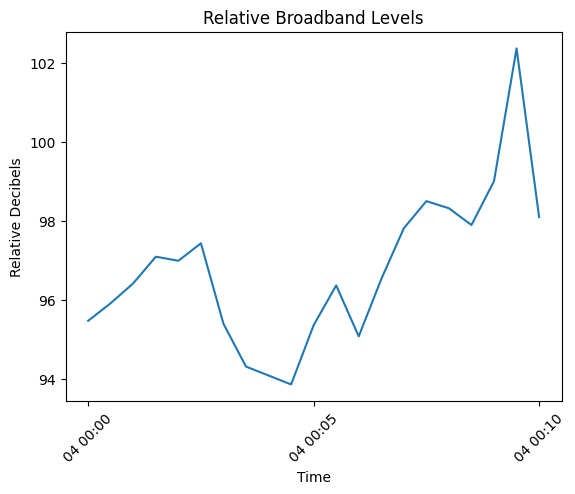

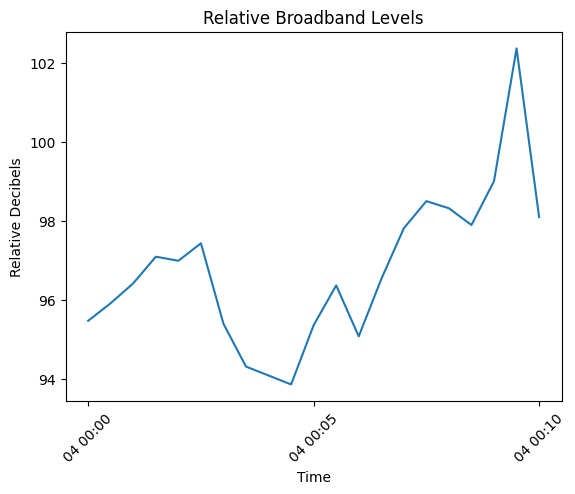

In [11]:
plot_bb(bb_df)